##### Carter Williams, Matthew Del Sol, Urooj Ali 
##### Predicting Supply Chain Disruptions and Recovery Times Using Machine Learning 
##### MGS4701
##### Md Golam Kibria 

# Importing Necessary Libraries

In [68]:
%matplotlib inline

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Import the dataset

In [71]:
df = pd.read_csv('supplychain-preprocessed.csv')

print(df.head())
print("Shape:", df.shape)

    disruption_type         industry  supplier_tier supplier_region  \
0  Factory Incident  Pharmaceuticals              1    Asia-Pacific   
1      Cyber Attack      Electronics              2    Asia-Pacific   
2   Port Congestion      Electronics              1    Asia-Pacific   
3      Labor Strike      Electronics              2          Europe   
4      Geopolitical      Electronics              1   South America   

  supplier_size  has_backup_supplier  disruption_severity  \
0         Large                    0                    2   
1        Medium                    1                    4   
2         Small                    1                    2   
3         Large                    1                    1   
4        Medium                    1                    2   

   production_impact_pct  revenue_loss_usd         response_type  \
0                   54.3       11376013.16        Customer Delay   
1                   52.4        1199054.59  Alternative Supplier   
2 

The preprocessed dataset from the earlier milestone was loaded to build the initial predictive model. The dataset includes disruption characteristics, supplier information, response variables, and recovery time measures.

## Review the Dataset Structure

In [72]:
df

,disruption_type,industry,supplier_tier,supplier_region,supplier_size,has_backup_supplier,disruption_severity,production_impact_pct,revenue_loss_usd,response_type,response_time_days,partial_recovery_days,full_recovery_days,permanent_supplier_change,severity_impact
0,Factory Incident,Pharmaceuticals,1,Asia-Pacific,Large,0,2,54.3,11376013.16,Customer Delay,14,3,59,0,108.6
1,Cyber Attack,Electronics,2,Asia-Pacific,Medium,1,4,52.4,1199054.59,Alternative Supplier,1,29,97,1,209.6
2,Port Congestion,Electronics,1,Asia-Pacific,Small,1,2,32.4,228848.77,Alternative Supplier,1,18,67,1,64.8
3,Labor Strike,Electronics,2,Europe,Large,1,1,15.7,2257287.82,Alternative Supplier,1,18,36,0,15.7
4,Geopolitical,Electronics,1,South America,Medium,1,2,32.9,965588.44,Alternative Supplier,7,11,61,1,65.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Port Congestion,Pharmaceuticals,1,North America,Medium,1,1,14.4,681354.68,Alternative Supplier,3,3,8,0,14.4
99996,Port Congestion,Pharmaceuticals,2,Asia-Pacific,Large,1,3,26.6,7549732.98,Alternative Supplier,5,9,153,0,79.8
99997,Port Congestion,Automotive,2,Europe,Medium,1,1,24.0,617965.56,Alternative Supplier,1,15,43,0,24.0
99998,Labor Strike,Pharmaceuticals,1,South America,Medium,1,1,16.9,429525.75,Alternative Supplier,4,21,59,1,16.9


# Model Choice

# Random Forest Regressor

We have chosen a Random Forest Regressor to predict the full_recovery_days. This approach is suitable because:

1. Problem Type: Predicting a continuous numerical value (days) is a regression task.

2. Data Nature: The dataset contains a mix of categorical (e.g., industry, disruption type) and numerical variables. Tree-based models like Random Forest handle these mixtures and non-linear relationships effectively without requiring extensive feature scaling.

3. Business Goal: Estimating "Time to Recovery" (TTR) is critical for supply chain resilience planning and risk mitigation.

# Define the Target Variable and Predictor Features

In [77]:
target = 'full_recovery_days'
features = [col for col in df.columns if col not in [target, 'partial_recovery_days']]

X = df[features].copy()
y = df[target]

The target variable is `full_recovery_days`. The variable `partial_recovery_days` was excluded from the predictors to reduce the risk of leakage and keep the model focused on disruption characteristics and response-related factors.

# Encode Categorical Variables

In [79]:
cat_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, drop_first=True)

Categorical variables were transformed using one-hot encoding so they could be used in the Random Forest model.

# Split the Data into Training and Testing Sets

In [100]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

The dataset was split into training and testing sets using an 80/20 split. The training set was used to build the model, and the testing set was used to evaluate its performance.

# Train the Initial Random Forest Model

In [83]:
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=50, random_state=42)

The initial Random Forest model was trained using 50 decision trees and a maximum depth of 10. These settings were selected to create a straightforward baseline model without extensive tuning.

# Evaluate Model Performance

In [84]:
y_pred = rf_model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} days")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} days")
print(f"R-squared (R2) Score: {r2:.4f}")

Mean Absolute Error (MAE): 30.87 days
Root Mean Squared Error (RMSE): 44.08 days
R-squared (R2) Score: 0.4012


The model was evaluated using MAE, RMSE, and R². These metrics help assess the average prediction error, the size of larger errors, and the proportion of variance explained by the model.

# Review Sample Predictions

In [85]:
sample_comparison = pd.DataFrame({'Actual Days': y_test[:5].values, 'Predicted Days': y_pred[:5].round(1)})
print("\nSample Predictions:")
print(sample_comparison)


Sample Predictions:
   Actual Days  Predicted Days
0           38            26.6
1           73           106.4
2          102            75.3
3           30            73.3
4          129           103.6


The sample predictions provide a quick comparison between actual and predicted recovery times. They show that the model can estimate general recovery ranges, although some predictions still differ noticeably from the actual values.

# Feature Importance Analysis

In [86]:
# Feature importance table
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

Top 10 Most Important Features:
                             Feature  Importance
2                disruption_severity    0.705822
1                has_backup_supplier    0.126509
4                   revenue_loss_usd    0.040871
7                    severity_impact    0.020328
3              production_impact_pct    0.019474
5                 response_time_days    0.015629
0                      supplier_tier    0.012337
24      response_type_Customer Delay    0.012183
6          permanent_supplier_change    0.007389
26  response_type_Production Reroute    0.006179


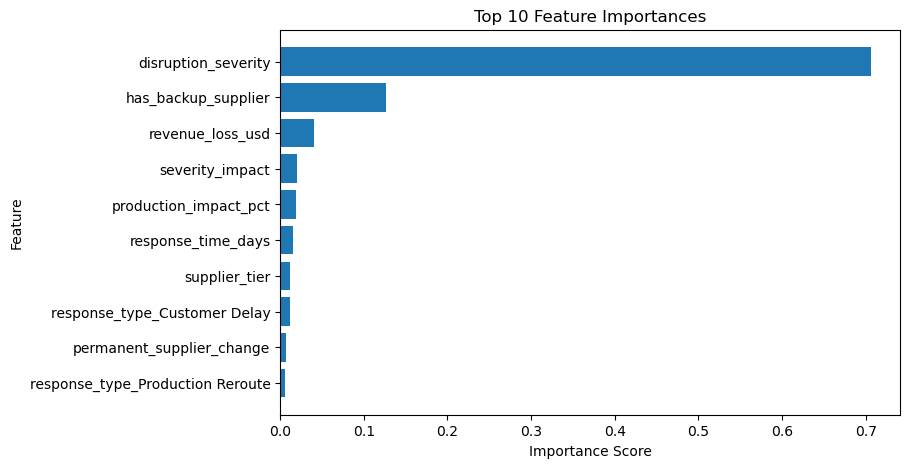

In [89]:
# Plot top feature importances
import matplotlib.pyplot as plt
top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

The feature importance results show that disruption severity is the most important predictor, as it is accounting for the majority of the model’s decision-making. This means that more severe disruptions lead to substantially longer recovery times.

The second most important variable is whether a backup supplier is available or not, indicating that supply chain redundancy plays a big role in reducing recovery duration.

Other variables such as revenue loss, production impact, and response time contribute to the model but have a smaller influence. These findings suggest that while multiple factors affect recovery time, severity and supply chain resilience are the primary drivers.

Results:
- Mean Absolute Error (MAE): About 30.87 days. On average, predictions are off by about one month.
- Root Mean Squared Error (RMSE): About 44.08 days, indicating that larger prediction errors can be significant.
R-Squared (R²): About 0.40, meaning the model explains roughly 40% of the variation in recovery times.
Top Predictors: disruption_severity (~70% importance) and has_backup_supplier (~12% importance).

The model provides a reasonable baseline for predicting recovery duration, though it is not highly precise. The results show that disruption severity is the most influential factor, which aligns with expectations that more severe disruptions require longer recovery times.

The importance of has_backup_supplier suggests that supply chain redundancy plays a meaningful role in reducing recovery time, making it an important operational consideration for businesses.

While other variables such as revenue loss, production impact, and response time contribute to predictions, their influence is smaller. The R² value indicates that the model captures some meaningful patterns, but a significant portion of variability remains unexplained.

Overall, the model identifies key drivers of recovery time and provides useful insights, but further improvements such as tuning parameters, testing alternative models, or engineering additional features could improve predictive performance.